# Task 2: genre LoRA adapter for Qwen3.5-4B

Fine-tunes a LoRA adapter on `Qwen/Qwen3.5-4B` so that the model **writes the genre name** of a story.
The base weights stay frozen. In vLLM one instance serves both tasks:
`model="qwen3.5-4b"` for the chatbot (Task 1, no adapter) and `model="genre-lora"` for classification (Task 2).

**Steps:** load data and split → build prompts → zero-shot baseline → LoRA training with a val check each epoch → test metrics → save the adapter for vLLM.

**Hardware:** A100 or L4, bf16 throughout (no quantization, so the adapter is trained on exactly the weights vLLM serves).

**Output folder** (`OUTPUT_DIR`):
- `adapter/` holds the LoRA adapter (`adapter_config.json`, `adapter_model.safetensors`), ready for `vllm serve --lora-modules`.
- `labels.json` and `prompt.json` hold the 100 genres and the exact system prompt. Serving must use the same ones.
- `results.json` and `*.png` hold the metrics and plots.

In [1]:
# Qwen3.5 needs transformers 5.x. flash-linear-attention gives fast Gated DeltaNet kernels on GPU;
# without it transformers falls back to a slower pure-PyTorch path (if its install fails, just drop it from the line).
%pip install -q "transformers>=5.2" "peft>=0.17" accelerate datasets scikit-learn matplotlib flash-linear-attention

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.6/399.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.2/819.2 kB 35.2 MB/s eta 0:00:00


## 1. Settings

In [2]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [5]:
!ls /gdrive/MyDrive/LORA/story-chatbot

story-chatbot


In [6]:
from pathlib import Path

MODEL_ID   = "Qwen/Qwen3.5-4B"
DATA_PATH  = None                       # None = Hugging Face dataset; or a local .csv / .parquet / .jsonl copy
DATASET_ID = "FareedKhan/1k_stories_100_genre"
SPLIT_PATH = None                       # optional splits.json from the chatbot project, so both tasks share one split
OUTPUT_DIR = Path("/gdrive/MyDrive/LORA/story-chatbot/genre_lora_qwen35")
SEED       = 42

# Prompt
MAX_STORY_TOKENS = 2048                 # stories are ~1.2k-2.5k tokens; longer ones keep their beginning

# LoRA. Only modules vLLM supports for Qwen3.5. in_proj_qkv and in_proj_z must be trained together
# (vLLM fuses them). in_proj_a / in_proj_b / conv1d and the vision tower are left alone.
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",          # 8 full-attention layers
                  "in_proj_qkv", "in_proj_z", "out_proj",          # 24 Gated DeltaNet layers
                  "gate_proj", "up_proj", "down_proj"]             # MLP in all 32 layers

# Training. Effective batch = BATCH_SIZE * GRAD_ACCUM = 16. On an L4 use BATCH_SIZE 2, GRAD_ACCUM 8.
EPOCHS, LR, WARMUP_FRAC, WEIGHT_DECAY = 5, 1e-4, 0.05, 0.0
BATCH_SIZE, GRAD_ACCUM = 2, 8
EVAL_BATCH = 4
PATIENCE   = 2                          # stop after this many epochs without a better val macro-F1

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Data and split

In [7]:
import json, random
import numpy as np, pandas as pd, torch

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if DATA_PATH:
    p = Path(DATA_PATH)
    df = {".csv": pd.read_csv, ".parquet": pd.read_parquet}.get(p.suffix, lambda f: pd.read_json(f, lines=True))(p)
else:
    from datasets import load_dataset
    df = load_dataset(DATASET_ID, split="train").to_pandas()
df = df[["id", "title", "genre", "story"]].astype({"title": str, "genre": str, "story": str})


def make_split(df, seed=42, val_frac=0.1, test_frac=0.2):
    # Same algorithm as storybot.data.splits.make_split: stratified per genre (7/1/2 for 10 stories).
    rng = np.random.default_rng(seed)
    split = {"train": [], "val": [], "test": []}
    for _, grp in df.groupby("genre"):
        ids = grp["id"].tolist()
        rng.shuffle(ids)
        n_test, n_val = max(1, round(test_frac * len(ids))), max(1, round(val_frac * len(ids)))
        split["test"] += ids[:n_test]
        split["val"] += ids[n_test:n_test + n_val]
        split["train"] += ids[n_test + n_val:]
    return split


split = json.loads(Path(SPLIT_PATH).read_text()) if SPLIT_PATH else make_split(df, SEED)
where = {str(i): s for s, ids in split.items() for i in ids}
df["split"] = df["id"].astype(str).map(where)
assert df["split"].notna().all(), "split file does not cover every story id"

LABELS = sorted(df["genre"].unique())
print(f"{len(df)} stories, {len(LABELS)} genres |", df["split"].value_counts().to_dict())

README.md:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

1k_stories_100_genre.csv:   0%|          | 0.00/5.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

1000 stories, 99 genres | {'train': 700, 'test': 200, 'val': 100}


## 3. Prompt

The system prompt lists all genres, so the base model already has a fair zero-shot baseline and the
adapter only has to learn to pick the right one. The chat template is applied with `enable_thinking=False`,
which is also how vLLM will be called. The target is the genre name followed by `<|im_end|>`, and loss is
computed on those tokens only.

In [8]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained(MODEL_ID)
tok.pad_token = tok.pad_token or "<|endoftext|>"
END = "<|im_end|>"

SYSTEM_PROMPT = ("You classify short stories by genre. Answer with exactly one genre from this list and nothing else.\n"
                 "Genres: " + "; ".join(LABELS))


def prompt_ids(title, story):
    story_ids = tok(story, add_special_tokens=False)["input_ids"][:MAX_STORY_TOKENS]
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Title: {title}\n\nStory:\n{tok.decode(story_ids)}"}]
    text = tok.apply_chat_template(messages, add_generation_prompt=True, enable_thinking=False, tokenize=False)
    return tok(text, add_special_tokens=False)["input_ids"]


def example(row):
    p = prompt_ids(row.title, row.story)
    t = tok(row.genre + END, add_special_tokens=False)["input_ids"]
    return {"input_ids": p + t, "labels": [-100] * len(p) + t}


data = {s: [example(r) for r in df[df.split == s].itertuples()] for s in ("train", "val", "test")}
lens = [len(x["input_ids"]) for x in data["train"]]
print(f"train sequence length: mean {np.mean(lens):.0f}, max {max(lens)}")
print(tok.decode(data["train"][0]["input_ids"])[-400:])

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

train sequence length: mean 1568, max 2433
nolds, sailed onward into the stars, their journey far from over. For they knew that there were still countless mysteries to uncover and challenges to face in the vast expanse of the cosmos. And as long as there were heroes to answer the call, the universe would remain a place of hope, wonder, and boundless possibilities.<|im_end|>
<|im_start|>assistant
<think>

</think>

Science Fiction<|im_end|>


## 4. Model and LoRA

In [10]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [11]:
from transformers import AutoModelForImageTextToText
from peft import LoraConfig, get_peft_model

# Load the same class vLLM serves (Qwen3_5ForConditionalGeneration). The adapter keys then come out as
# ...model.language_model.layers..., which is the layout vLLM expects. A text-only load would save
# ...model.layers... keys, and vLLM would load that adapter as a silent no-op.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to(device)
model.config.use_cache = False
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.enable_input_require_grads()

lora_cfg = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT, bias="none",
                      target_modules=TARGET_MODULES, exclude_modules=r".*visual.*", task_type="CAUSAL_LM")
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

adapted = [n for n, m in model.named_modules() if hasattr(m, "lora_A") and n.endswith(tuple(TARGET_MODULES))]
assert adapted and all("language_model" in n for n in adapted), "LoRA must sit only on the language model"
print(len(adapted), "layers adapted, e.g.", adapted[0])

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

trainable params: 30,474,240 || all params: 4,569,739,776 || trainable%: 0.6669
200 layers adapted, e.g. base_model.model.model.language_model.layers.0.linear_attn.out_proj


## 5. Evaluation

Greedy generation of a few tokens, then exact match against the label list. Outputs that are not an exact
genre are mapped to the closest one and counted as `invalid_rate`. In vLLM, `structured_outputs` restricts the
output to the 100 labels, so invalid outputs can't happen there.

In [12]:
import difflib, time
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

lower = {g.lower(): g for g in LABELS}


@torch.no_grad()
def predict(examples, use_adapter=True):
    model.eval()
    tok.padding_side = "left"
    preds, invalid = [], 0
    for i in range(0, len(examples), EVAL_BATCH):
        prompts = [[t for t, l in zip(x["input_ids"], x["labels"]) if l == -100] for x in examples[i:i + EVAL_BATCH]]
        batch = tok.pad({"input_ids": prompts}, return_tensors="pt").to(device)
        gen_kwargs = dict(**batch, max_new_tokens=16, do_sample=False, use_cache=True, pad_token_id=tok.pad_token_id)
        if use_adapter:
            out = model.generate(**gen_kwargs)
        else:
            with model.disable_adapter():
                out = model.generate(**gen_kwargs)
        for text in tok.batch_decode(out[:, batch["input_ids"].shape[1]:], skip_special_tokens=True):
            text = text.strip()
            if text.lower() in lower:
                preds.append(lower[text.lower()])
            else:
                invalid += 1
                preds.append((difflib.get_close_matches(text, LABELS, n=1, cutoff=0) or [LABELS[0]])[0])
    tok.padding_side = "right"
    return preds, invalid / max(1, len(examples))


def evaluate(split_name, use_adapter=True):
    gold = df[df.split == split_name]["genre"].tolist()
    preds, invalid = predict(data[split_name], use_adapter)
    return {"accuracy": accuracy_score(gold, preds), "macro_f1": f1_score(gold, preds, average="macro", zero_division=0),
            "invalid_rate": invalid}, gold, preds


t0 = time.time()
baseline, *_ = evaluate("val", use_adapter=False)
print("zero-shot base model on val:", baseline, f"({time.time() - t0:.0f}s)")

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


zero-shot base model on val: {'accuracy': 0.39, 'macro_f1': 0.3353382307927762, 'invalid_rate': 0.01} (103s)


## 6. Training

In [13]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup


def collate(batch):
    n = max(len(x["input_ids"]) for x in batch)
    ids = torch.full((len(batch), n), tok.pad_token_id)
    labels = torch.full((len(batch), n), -100)
    mask = torch.zeros((len(batch), n), dtype=torch.long)
    for i, x in enumerate(batch):
        k = len(x["input_ids"])
        ids[i, :k], labels[i, :k], mask[i, :k] = torch.tensor(x["input_ids"]), torch.tensor(x["labels"]), 1
    return {"input_ids": ids, "labels": labels, "attention_mask": mask}


loader = DataLoader(data["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
                    generator=torch.Generator().manual_seed(SEED))
steps = EPOCHS * -(-len(loader) // GRAD_ACCUM)
params = [p for p in model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
sched = get_cosine_schedule_with_warmup(opt, int(WARMUP_FRAC * steps), steps)

ADAPTER_DIR = OUTPUT_DIR / "adapter"
history = [{"epoch": 0, "train_loss": None, **{f"val_{k}": v for k, v in baseline.items()}}]
best_f1, bad_epochs, t_train = -1.0, 0, time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for step, batch in enumerate(loader):
        loss = model(**{k: v.to(device) for k, v in batch.items()}).loss
        (loss / GRAD_ACCUM).backward()
        losses.append(loss.item())
        if (step + 1) % GRAD_ACCUM == 0 or step + 1 == len(loader):
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step(); sched.step(); opt.zero_grad(set_to_none=True)

    val, *_ = evaluate("val")
    history.append({"epoch": epoch, "train_loss": float(np.mean(losses)), **{f"val_{k}": v for k, v in val.items()}})
    print(f"epoch {epoch}: loss {np.mean(losses):.4f} | val acc {val['accuracy']:.3f} "
          f"macro-F1 {val['macro_f1']:.3f} invalid {val['invalid_rate']:.2f} | {(time.time() - t_train) / 60:.1f} min")

    if val["macro_f1"] > best_f1:
        best_f1, bad_epochs = val["macro_f1"], 0
        model.save_pretrained(ADAPTER_DIR)              # adapter only (a few tens of MB)
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("early stop"); break

train_minutes = (time.time() - t_train) / 60
print(f"best val macro-F1 {best_f1:.3f}, training took {train_minutes:.1f} min")

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


epoch 1: loss 0.4152 | val acc 0.730 macro-F1 0.664 invalid 0.01 | 10.9 min
epoch 2: loss 0.2263 | val acc 0.720 macro-F1 0.657 invalid 0.00 | 19.8 min
epoch 3: loss 0.1371 | val acc 0.710 macro-F1 0.649 invalid 0.00 | 28.7 min
early stop
best val macro-F1 0.664, training took 28.7 min


## 7. Test metrics (best adapter)

test, base model : {'accuracy': 0.385, 'macro_f1': 0.34011443102352196, 'invalid_rate': 0.0}
test, with LoRA  : {'accuracy': 0.65, 'macro_f1': 0.6156354307869459, 'invalid_rate': 0.005}
macro precision 0.655 recall 0.646 F1 0.616
                         precision    recall  f1-score   support

              Adventure       0.67      1.00      0.80         2
    Alternate Dimension       1.00      1.00      1.00         2
      Alternate History       1.00      0.50      0.67         2
      Alternate Reality       1.00      0.50      0.67         2
         Animal Fantasy       0.50      0.50      0.50         2
         Animal Fiction       1.00      0.50      0.67         2
              Anthology       1.00      1.00      1.00         2
            Apocalyptic       0.40      1.00      0.57         2
     Apocalyptic Comedy       1.00      1.00      1.00         2
Artificial Intelligence       1.00      1.00      1.00         2
         Artistic Drama       0.50      1.00      0.67

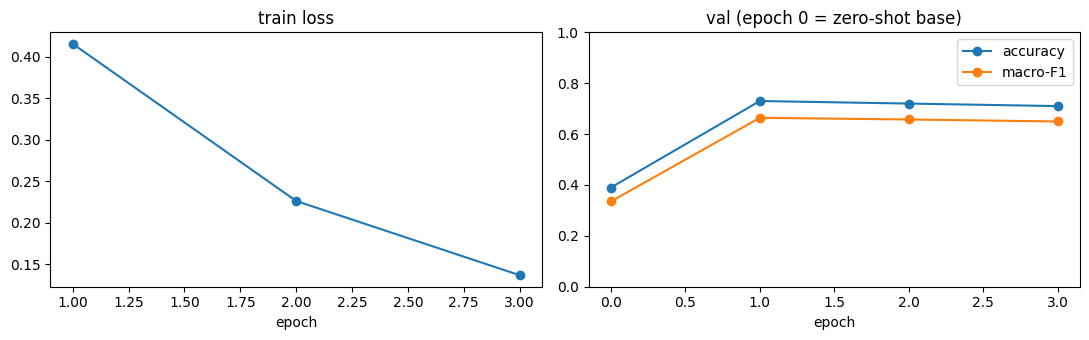

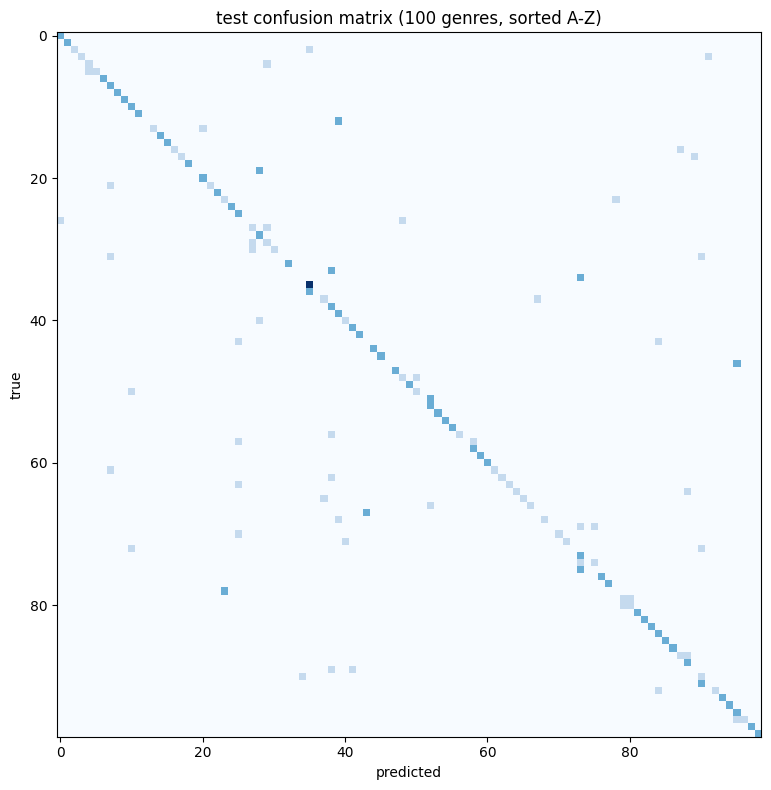

most confused (true -> predicted): [('Comedy', 'Humor', 2), ('Domestic Fiction', 'Family Drama', 2), ('Gothic', 'Horror', 2), ('Hard Science Fiction', 'Space Exploration', 2), ('Historical Fiction', 'Historical Adventure', 2), ('Military Fiction', 'War', 2), ('Mythic Fiction', 'Mythology', 2), ('Romantic Fantasy', 'Magical Realism', 2), ('Space Thriller', 'Space Exploration', 2), ('Spy Fiction', 'Espionage', 2)]


In [14]:
from peft import set_peft_model_state_dict
from safetensors.torch import load_file
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

set_peft_model_state_dict(model, load_file(ADAPTER_DIR / "adapter_model.safetensors"))
test, gold, preds = evaluate("test")
test_base, *_ = evaluate("test", use_adapter=False)
print("test, base model :", test_base)
print("test, with LoRA  :", test)
p, r, f, _ = precision_recall_fscore_support(gold, preds, average="macro", zero_division=0)
print(f"macro precision {p:.3f} recall {r:.3f} F1 {f:.3f}")
print(classification_report(gold, preds, zero_division=0))

hist = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist.epoch[1:], hist.train_loss[1:], marker="o"); ax[0].set(title="train loss", xlabel="epoch")
ax[1].plot(hist.epoch, hist.val_accuracy, marker="o", label="accuracy")
ax[1].plot(hist.epoch, hist.val_macro_f1, marker="o", label="macro-F1")
ax[1].set(title="val (epoch 0 = zero-shot base)", xlabel="epoch", ylim=(0, 1)); ax[1].legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=120); plt.show()

cm = confusion_matrix(gold, preds, labels=LABELS)
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(cm, cmap="Blues"); ax.set(title="test confusion matrix (100 genres, sorted A-Z)", xlabel="predicted", ylabel="true")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=120); plt.show()

confusions = [(LABELS[i], LABELS[j], int(cm[i, j])) for i in range(len(LABELS)) for j in range(len(LABELS)) if i != j and cm[i, j]]
print("most confused (true -> predicted):", sorted(confusions, key=lambda c: -c[2])[:10])

## 8. Save for vLLM

Checks that the adapter keys use the `language_model` layout vLLM expects and that `in_proj_qkv` and
`in_proj_z` appear together, then writes the labels, prompt and results next to the adapter and zips everything.

In [15]:
import shutil

keys = list(load_file(ADAPTER_DIR / "adapter_model.safetensors").keys())
assert all(".language_model." in k for k in keys), keys[:3]
assert any("in_proj_qkv" in k for k in keys) == any("in_proj_z" in k for k in keys)
print(len(keys), "tensors, e.g.", keys[0])

(OUTPUT_DIR / "labels.json").write_text(json.dumps(LABELS, indent=1))
(OUTPUT_DIR / "prompt.json").write_text(json.dumps({
    "system_prompt": SYSTEM_PROMPT, "user_template": "Title: {title}\n\nStory:\n{story}",
    "max_story_tokens": MAX_STORY_TOKENS, "enable_thinking": False}, indent=1))
(OUTPUT_DIR / "results.json").write_text(json.dumps({
    "model": MODEL_ID, "lora": {"r": LORA_R, "alpha": LORA_ALPHA, "dropout": LORA_DROPOUT, "target_modules": TARGET_MODULES},
    "training": {"epochs_run": len(history) - 1, "lr": LR, "effective_batch": BATCH_SIZE * GRAD_ACCUM,
                 "minutes": round(train_minutes, 1), "gpu": torch.cuda.get_device_name() if torch.cuda.is_available() else "cpu"},
    "history": history, "test_base": test_base, "test_lora": test}, indent=1, default=float))

archive = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("saved", archive)

400 tensors, e.g. base_model.model.model.language_model.layers.0.linear_attn.in_proj_qkv.lora_A.weight
saved /gdrive/MyDrive/LORA/story-chatbot/genre_lora_qwen35.zip


## 9. Serving it (reference)

```bash
vllm serve Qwen/Qwen3.5-4B --served-model-name qwen3.5-4b --language-model-only \
  --max-model-len 32768 --reasoning-parser qwen3 \
  --enable-auto-tool-choice --tool-call-parser qwen3_coder \
  --default-chat-template-kwargs '{"enable_thinking": false}' \
  --enable-lora --max-loras 1 --max-lora-rank 16 \
  --lora-modules genre-lora=genre_lora_qwen35/adapter
```

```python
from openai import OpenAI
cfg, labels = json.load(open("genre_lora_qwen35/prompt.json")), json.load(open("genre_lora_qwen35/labels.json"))
client = OpenAI(base_url="http://localhost:8000/v1", api_key="none")
r = client.chat.completions.create(
    model="genre-lora",                                    # "qwen3.5-4b" = base model for the chatbot
    messages=[{"role": "system", "content": cfg["system_prompt"]},
              {"role": "user", "content": cfg["user_template"].format(title=title, story=story)}],  # story cut to max_story_tokens
    temperature=0, max_tokens=16,
    extra_body={"structured_outputs": {"choice": labels}})
print(r.choices[0].message.content)
```